In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_train_path='/content/drive/MyDrive/Ai lab/Fruits_Vegetables/Fruits_Vegetables/train'
data_test_path='/content/drive/MyDrive/Ai lab/Fruits_Vegetables/Fruits_Vegetables/test'
data_val_path='/content/drive/MyDrive/Ai lab/Fruits_Vegetables/Fruits_Vegetables/validation'

In [ ]:
img_width=170
img_height=170

In [ ]:
data_train =tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(img_width,img_height),
    shuffle=True,
    validation_split=False)

Found 3115 files belonging to 36 classes.


In [ ]:
data_cat = data_train.class_names

In [ ]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [ ]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [ ]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 359 files belonging to 36 classes.


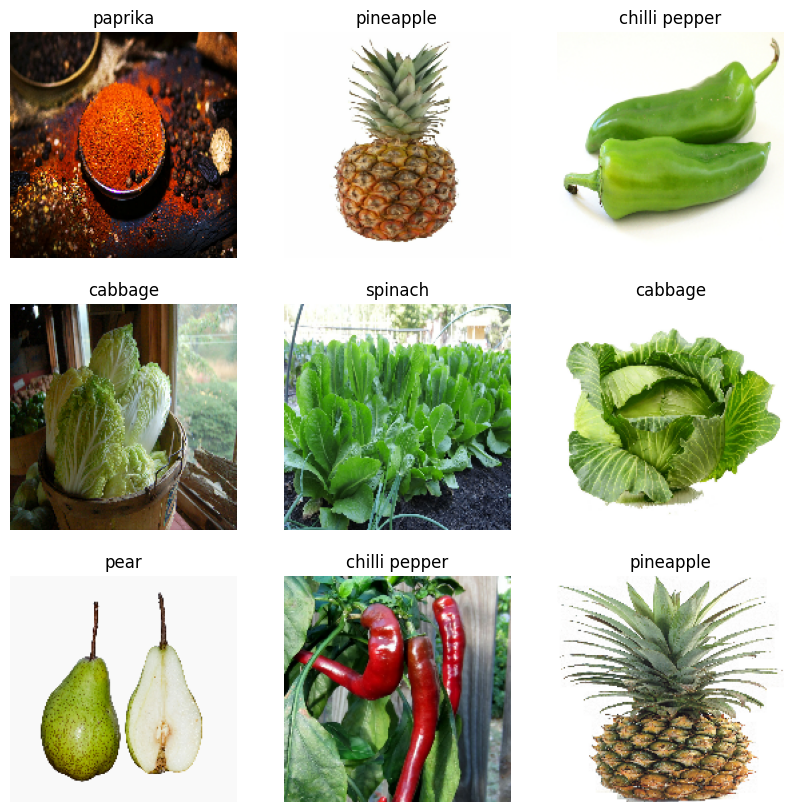

In [ ]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 170, 170, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))

])

NameError: name 'Sequential' is not defined

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

NameError: name 'model' is not defined

In [ ]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 630s 6s/step - accuracy: 0.0787 - loss: 3.6016 - val_accuracy: 0.3390 - val_loss: 2.4044
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.2799 - loss: 2.4790 - val_accuracy: 0.5954 - val_loss: 1.4135
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.4191 - loss: 1.9456 - val_accuracy: 0.7607 - val_loss: 0.9196
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.6208 - loss: 1.3270 - val_accuracy: 0.8234 - val_loss: 0.6858
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7721 - loss: 0.7787 - val_accuracy: 0.9031 - val_loss: 0.4240
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.8633 - loss: 0.4913 - val_accuracy: 0.9145 - val_loss: 0.4262
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.9317 - loss: 0.2786 - val_accuracy: 0.9459 - val_loss: 0.3241
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9455 - loss: 0.2268 - val_accuracy: 0.9430 - v

Text(0.5, 1.0, 'Loss')

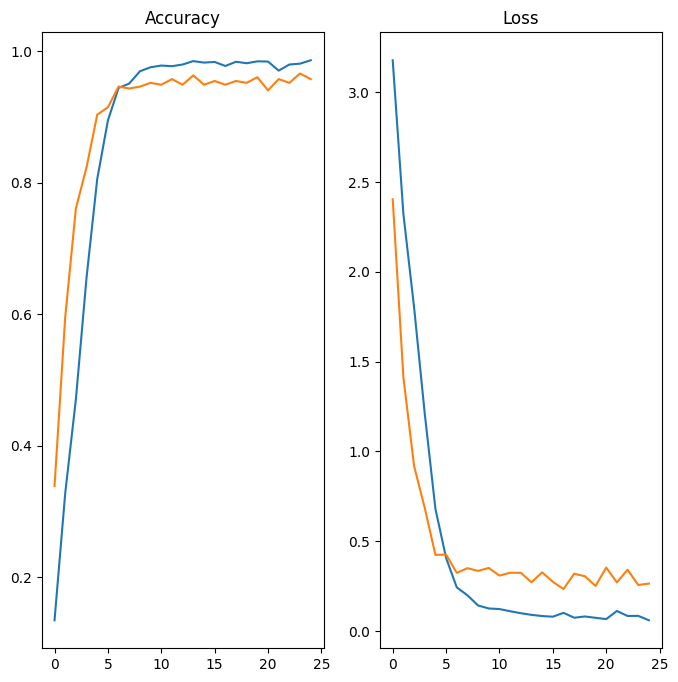

In [ ]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [ ]:
image = 'corn.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [ ]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step


In [ ]:
score = tf.nn.softmax(predict)

In [ ]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is pear with accuracy of 99.25


In [ ]:
model.save('Image_classify.keras')

**App for image classification:**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import  load_model
import streamlit as st
import numpy as np

st.header('Image Classification Model')
model = load_model('C:\Python\Image_Classification\Image_classify.keras')
data_cat = ['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']
img_height = 180
img_width = 180
image =st.text_input('Enter Image name','Apple.jpg')

image_load = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image_load)
img_bat=tf.expand_dims(img_arr,0)

predict = model.predict(img_bat)

score = tf.nn.softmax(predict)
st.image(image, width=200)
st.write('Veg/Fruit in image is ' + data_cat[np.argmax(score)])
st.write('With accuracy of ' + str(np.max(score)*100))